# Step 2: Exploratory Data Analysis & Cleaning
Online Retail Dataset — 5000-row sample

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

df = pd.read_csv('../data/raw/online_retail_sample.csv', parse_dates=['InvoiceDate'])
print(df.shape)
df.head()

(5000, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,575867,23242,TREASURE TIN BUFFALO BILL,6,2011-11-11 12:44:00,2.08,15034.0,United Kingdom
1,559899,37450,CERAMIC CAKE BOWL + HANGING CAKES,12,2011-07-13 12:24:00,2.95,12528.0,Germany
2,569401,23271,CHRISTMAS TABLE SILVER CANDLE SPIKE,16,2011-10-04 08:56:00,0.83,15111.0,United Kingdom
3,560041,22625,RED KITCHEN SCALES,2,2011-07-14 14:46:00,8.50,14156.0,EIRE
4,548257,85099B,JUMBO BAG RED RETROSPOT,200,2011-03-30 10:54:00,1.65,13802.0,United Kingdom


## 2.1 Basic Info

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    5000 non-null   int64         
 1   StockCode    5000 non-null   str           
 2   Description  5000 non-null   str           
 3   Quantity     5000 non-null   int64         
 4   InvoiceDate  5000 non-null   datetime64[us]
 5   UnitPrice    5000 non-null   float64       
 6   CustomerID   5000 non-null   float64       
 7   Country      5000 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 532.6 KB


In [3]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
count,5000.000000,5000.000000,5000,5000.000000,5000.000000
mean,560561.552600,11.857000,2011-07-10 07:35:58.752000,2.943810,15270.825200
min,536377.000000,1.000000,2010-12-01 09:34:00,0.120000,12347.000000
25%,548723.250000,2.000000,2011-04-04 05:04:00,1.250000,13892.000000
50%,561892.500000,6.000000,2011-07-31 14:39:30,1.950000,15136.000000
75%,572107.250000,12.000000,2011-10-20 17:26:45,3.750000,16770.000000
max,581587.000000,2000.000000,2011-12-09 12:50:00,376.500000,18287.000000
std,13229.179084,43.018023,NaN,6.457117,1706.946658


In [4]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicates: 2


## 2.2 Cleaning

In [5]:
df = df.drop_duplicates()
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

# Remove returns and zero-price items (already filtered in download, but double-check)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f'Clean dataset: {df.shape[0]} rows, {df["CustomerID"].nunique()} unique customers')

Clean dataset: 4998 rows, 2009 unique customers


## 2.3 Exploratory Visualizations

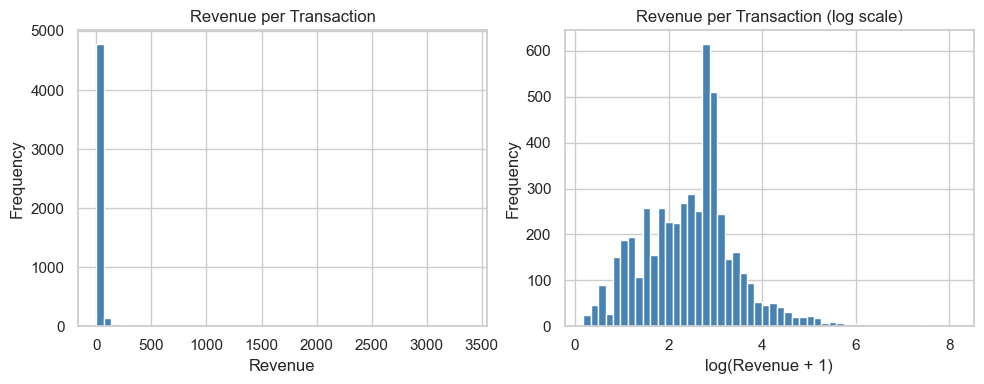

In [6]:
# Revenue distribution (log scale to handle skew)
fig, axes = plt.subplots(1, 2)

df['Revenue'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Revenue per Transaction')
axes[0].set_xlabel('Revenue')

np.log1p(df['Revenue']).plot(kind='hist', bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Revenue per Transaction (log scale)')
axes[1].set_xlabel('log(Revenue + 1)')

plt.tight_layout()
plt.savefig('../data/processed/revenue_distribution.png', dpi=150)
plt.show()

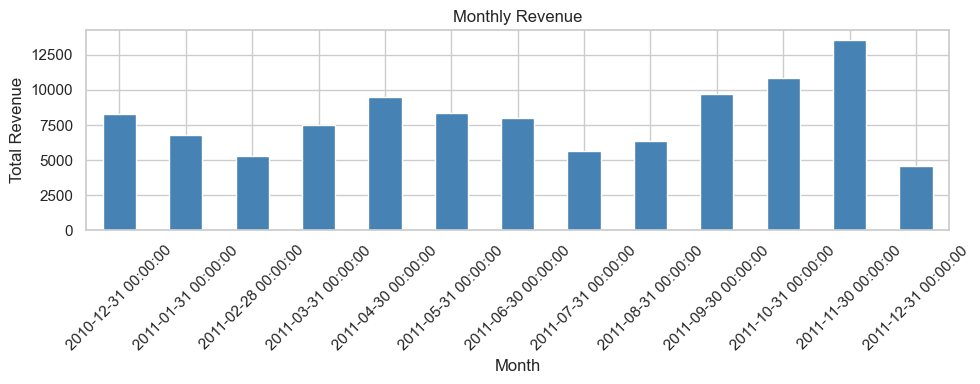

In [7]:
# Revenue over time
monthly = df.set_index('InvoiceDate').resample('ME')['Revenue'].sum()
monthly.plot(kind='bar', color='steelblue')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/monthly_revenue.png', dpi=150)
plt.show()

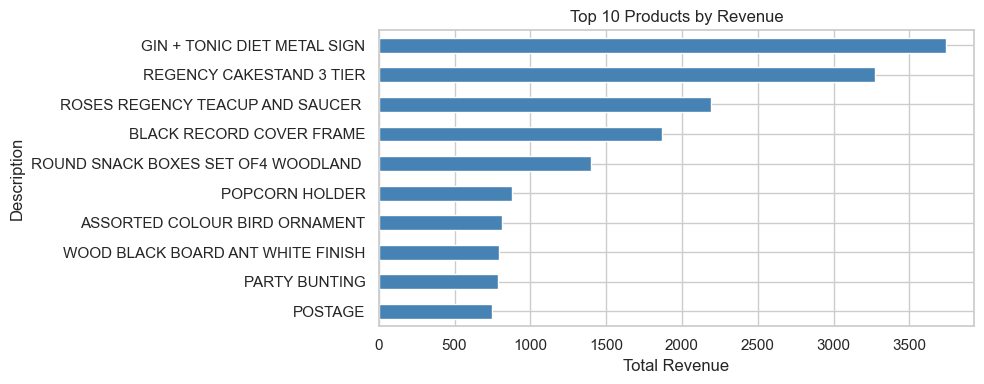

In [8]:
# Top 10 products by revenue
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/processed/top_products.png', dpi=150)
plt.show()

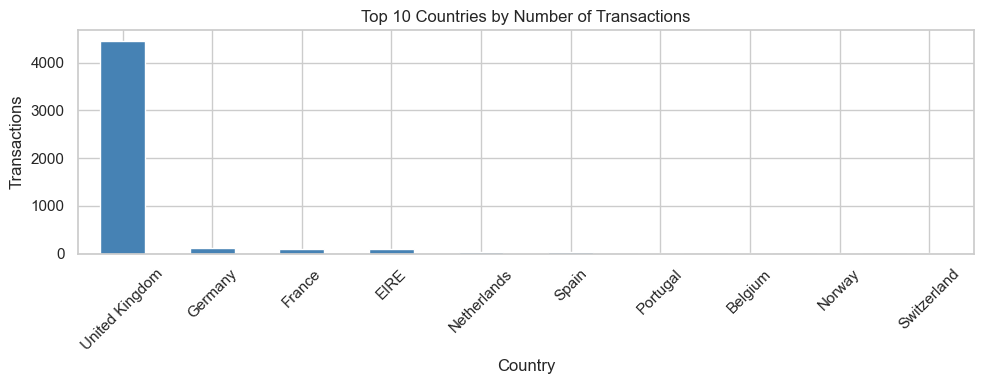

In [9]:
# Orders per country (top 10)
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Country')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/top_countries.png', dpi=150)
plt.show()

## 2.4 Save Cleaned Data

In [10]:
df.to_csv('../data/processed/online_retail_clean.csv', index=False)
print('Saved to data/processed/online_retail_clean.csv')

Saved to data/processed/online_retail_clean.csv
